<center><h1>Typical Sample Analysis of Clusters with Self-Organizing Maps (SOM) and K-means</h1></center>

In the representativity module of the IntraSOM library we implement some metrics to:
1) Calculate the responsibility of SOM neurons to the clusters obtained with K-means according to a Cluster Membership Probability Function (CMPF), inspired by mixture models;
2) Infer the clusters weights using a probabilistic approach;
3) Select typical samples from clusters using the Silhouette Coefficient (SC).

To understand the CMPF, we illustrate how clustering is done by the IntraSOM clustering module (Figure 1).
<div style="text-align: center; padding: 0px;">
  <img src="images/som_kmeans_clustering.jpg" style="max-width: 400px;">
</div>
<div style="text-align: center; font-size: 90%;">
<strong>Figure 1 –</strong> <em>
Two-stage clustering with SOM and a centroid-based clustering method.  
(A) Dataset with two cluster structures. (B) First-stage clustering with SOM, forming proto-clusters of samples; red lines represent high dissimilarity boundaries.  
(C) Second-stage clustering with a centroid-based method, resulting in clusters of neurons.  
(D) Two final clusters of samples.
</em>
</div>

In [1]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Toy datasets
from sklearn import datasets

# Processing
import intrasom
from intrasom import SOMFactory
from intrasom.visualization import PlotFactory
from intrasom.clustering import ClusterFactory
from intrasom.representativity import ClusterRepresentativity
from intrasom.nonsupervised_eval import Evaluation

# Post processing
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

c:\Users\gusta\InTRA\IntraSOM\intrasom-venv\Lib\site-packages\intrasom\visualization.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Load dataset
iris = datasets.load_iris(as_frame=True)
target_mapping = {
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
}

# Apply the mapping to the 'target' column
iris.frame['target'] = iris.frame['target'].map(target_mapping)
iris.frame.rename(columns={'target':'species'}, inplace=True)

iris.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Loading dataframe...
Normalizing data...
Creating neighborhood...
Initializing map...


Creating Neuron Distance Rows:   0%|          | 0/6 [00:00<?, ?rows/s]

Starting Training...
Rough Training:


  0%|          | 0/12 [00:00<?, ?it/s]

Fine Tuning:


  0%|          | 0/20 [00:00<?, ?it/s]

Training Report Created
Training completed successfully.


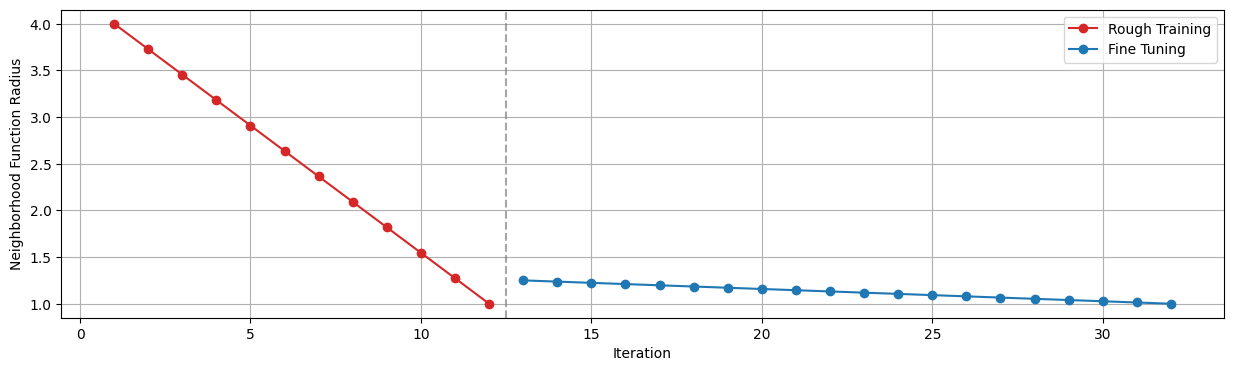

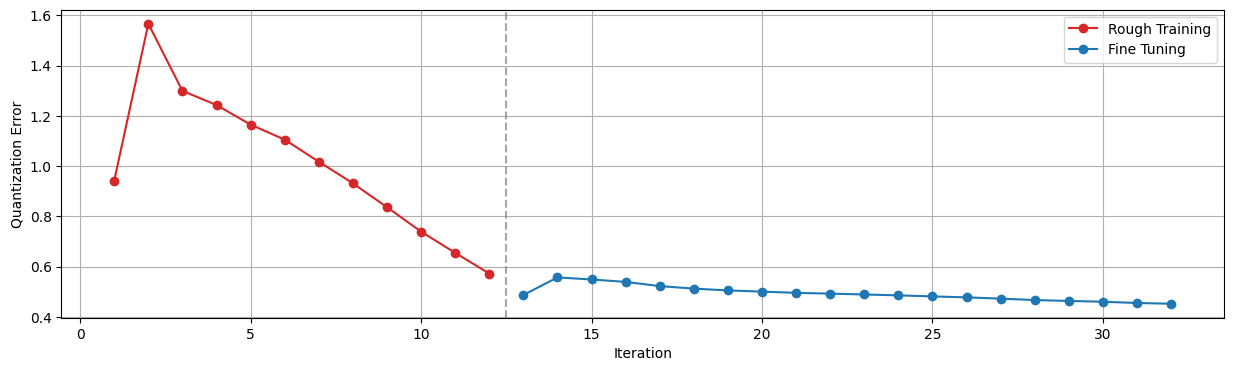

In [3]:
# Processing with SOM
mapsize = (10,6) # Vesanto's heuristic: 5*sqrt(150) ~ 60 neurons
som_iris = intrasom.SOMFactory.build(
    data = iris.data,
    mapsize = mapsize,
    mapshape = 'toroid',
    lattice = 'hexa',
    normalization = 'var',
    initialization = 'random',
    neighborhood = 'gaussian',
    training = 'batch',
    name = 'SOM_iris_dataset',
    component_names = iris.feature_names,
    unit_names = ['cm', 'cm', 'cm', 'cm'],
    missing = False)

# Training of the SOM
som_iris.train(qe_plot=True, radius_plot=True, plot_figsize=(15,4), save=False)

SOM and KNN oversampling result
Mapsize: 10x6 (60 neurons)
Number of new samples (BMUs): 44


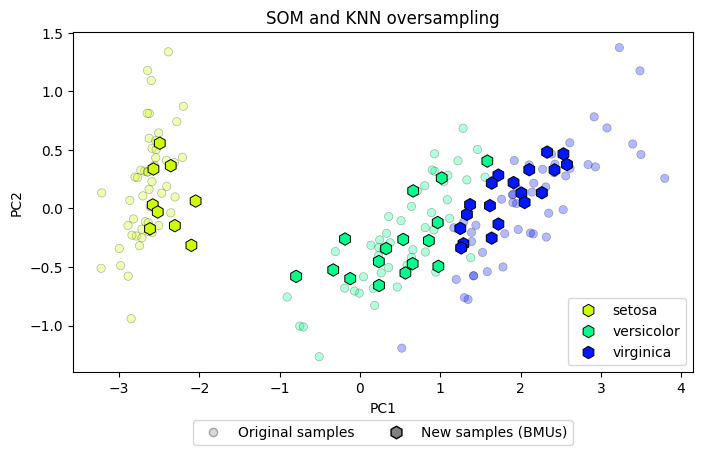

Label
virginica     19
versicolor    16
setosa         9
Name: count, dtype: int64

In [4]:
# Perform a KNN oversampling
eval_iris = Evaluation(som_iris)
new_samples = eval_iris.knn_oversampling(
    samples_labels=iris.frame['species'],
    normalized=False,
    pca_plot=True,
    plt_figsize=(8,5))
new_samples['Label'].value_counts()

In [5]:
# Visualization module
plot_iris = PlotFactory(som_iris)

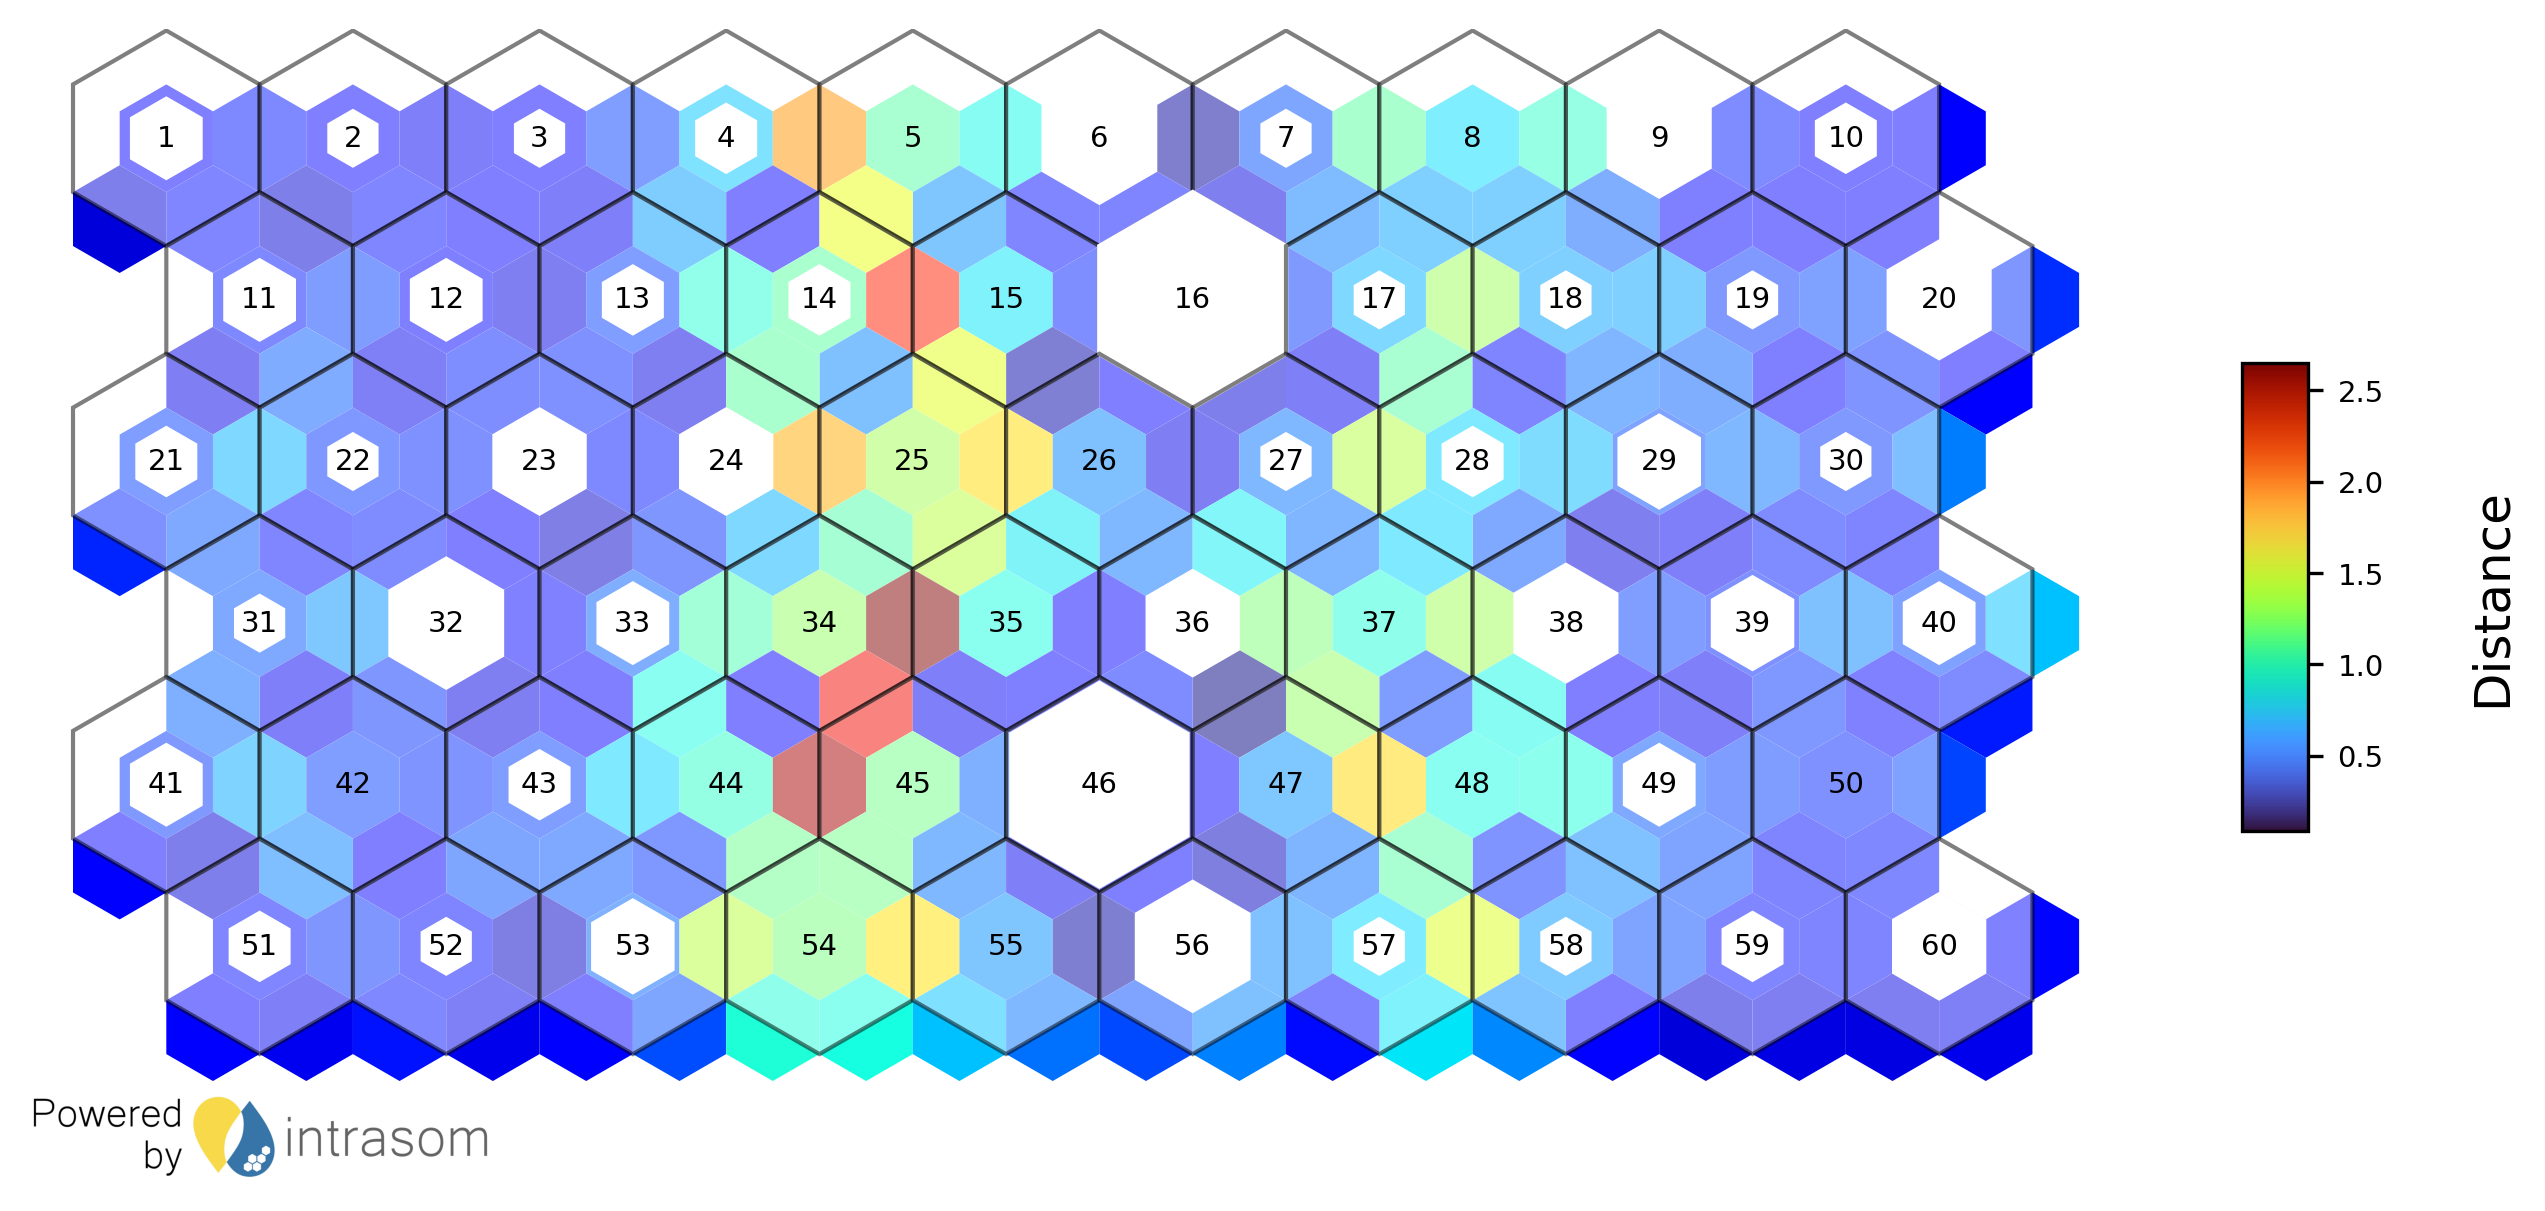

In [6]:
# U-matrix visualization: SOM space
plot_iris.plot_umatrix(
    figsize = (10,5),
    hits = True, # hits as white hexagons
    title = "",
    title_pad = 25,
    legend_title_size = 12,
    legend_ticks_size = 7,
    label_title_xy = (0,0.5),
    save = False,
    watermark_neurons=True, # template with the number of each neuron
    neurons_fontsize = 7)

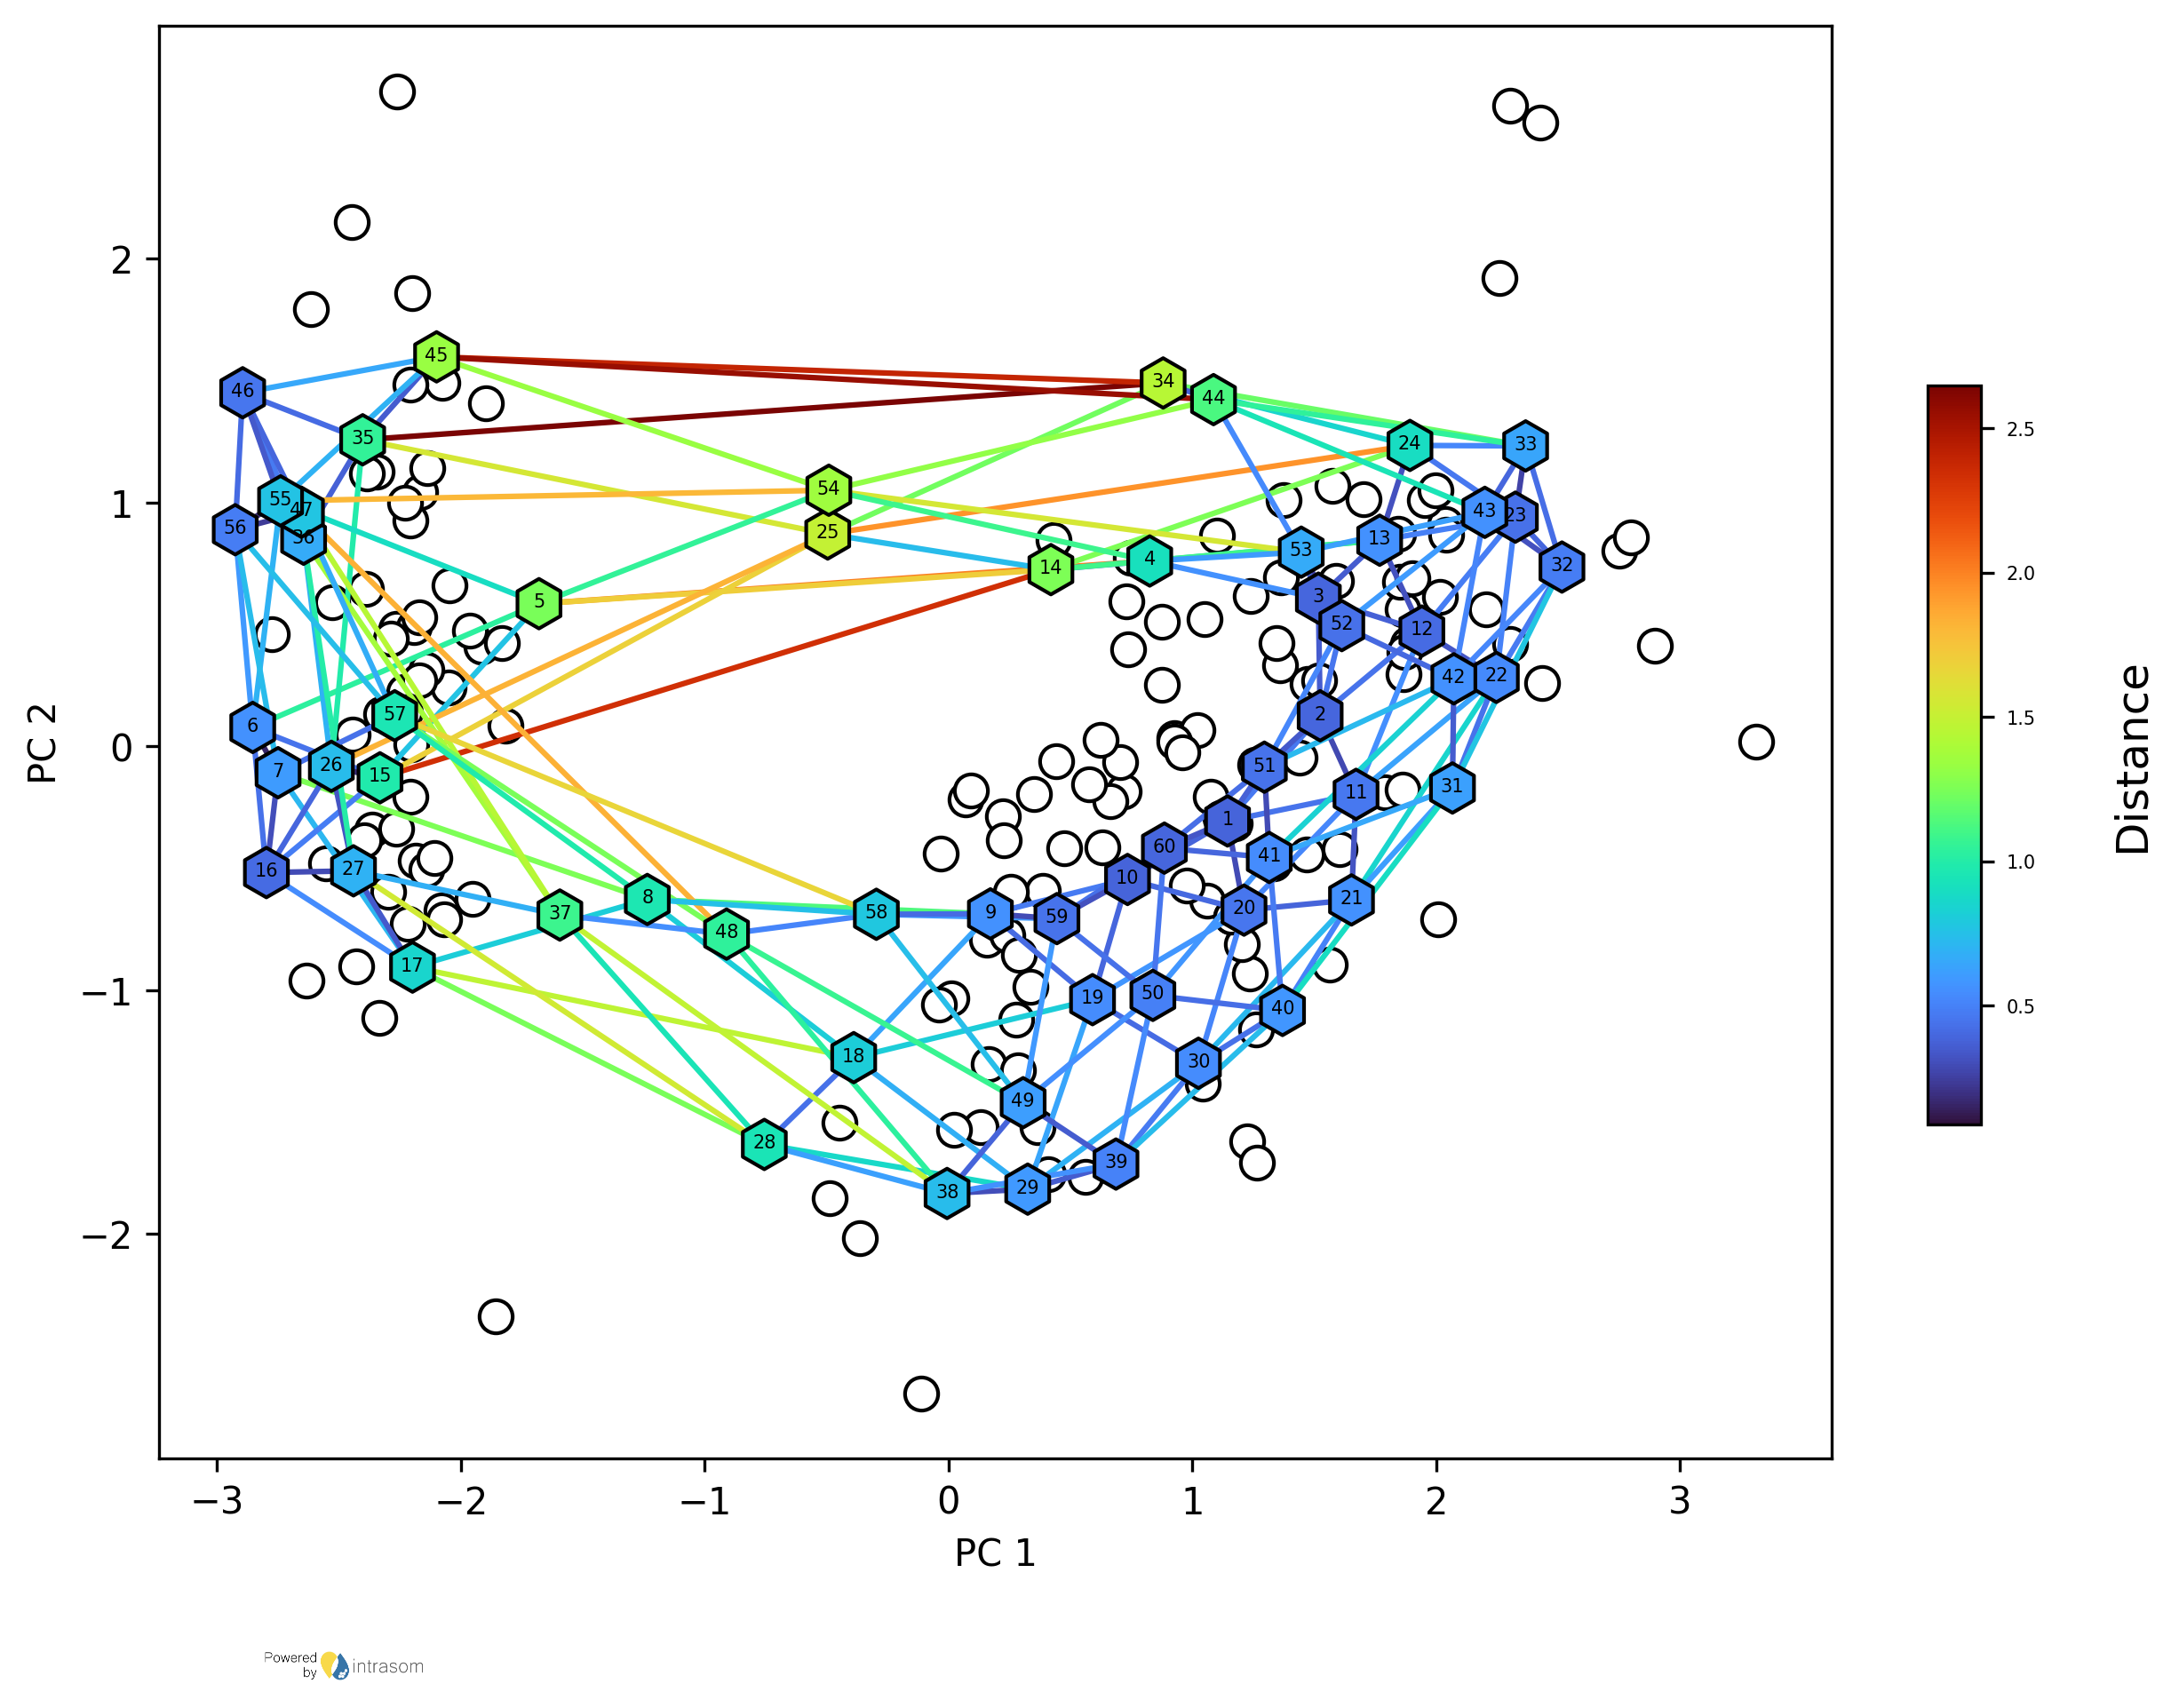

In [7]:
# U-matrix visualization: PCA space
plot_iris.plot_som_pca(
    figsize=(9,9),
    normalization='var', # the same as before
    title="",
    legend_title_size = 12,
    show_samples = True,
    samples_size = 80, # white circles
    show_connections = True, # lines connecting neighboring neurons
    connections_linewidth = 1.5,
    show_neurons = True,
    neurons_size = 180, # hexagons
    watermark_neurons = True # neurons template
)

In [8]:
# Clustering module
clustering_iris = ClusterFactory(som_iris)
clusters_iris = clustering_iris.kmeans(k=3) # k = 3, since we know the iris species are setosa, versicolor and virginica

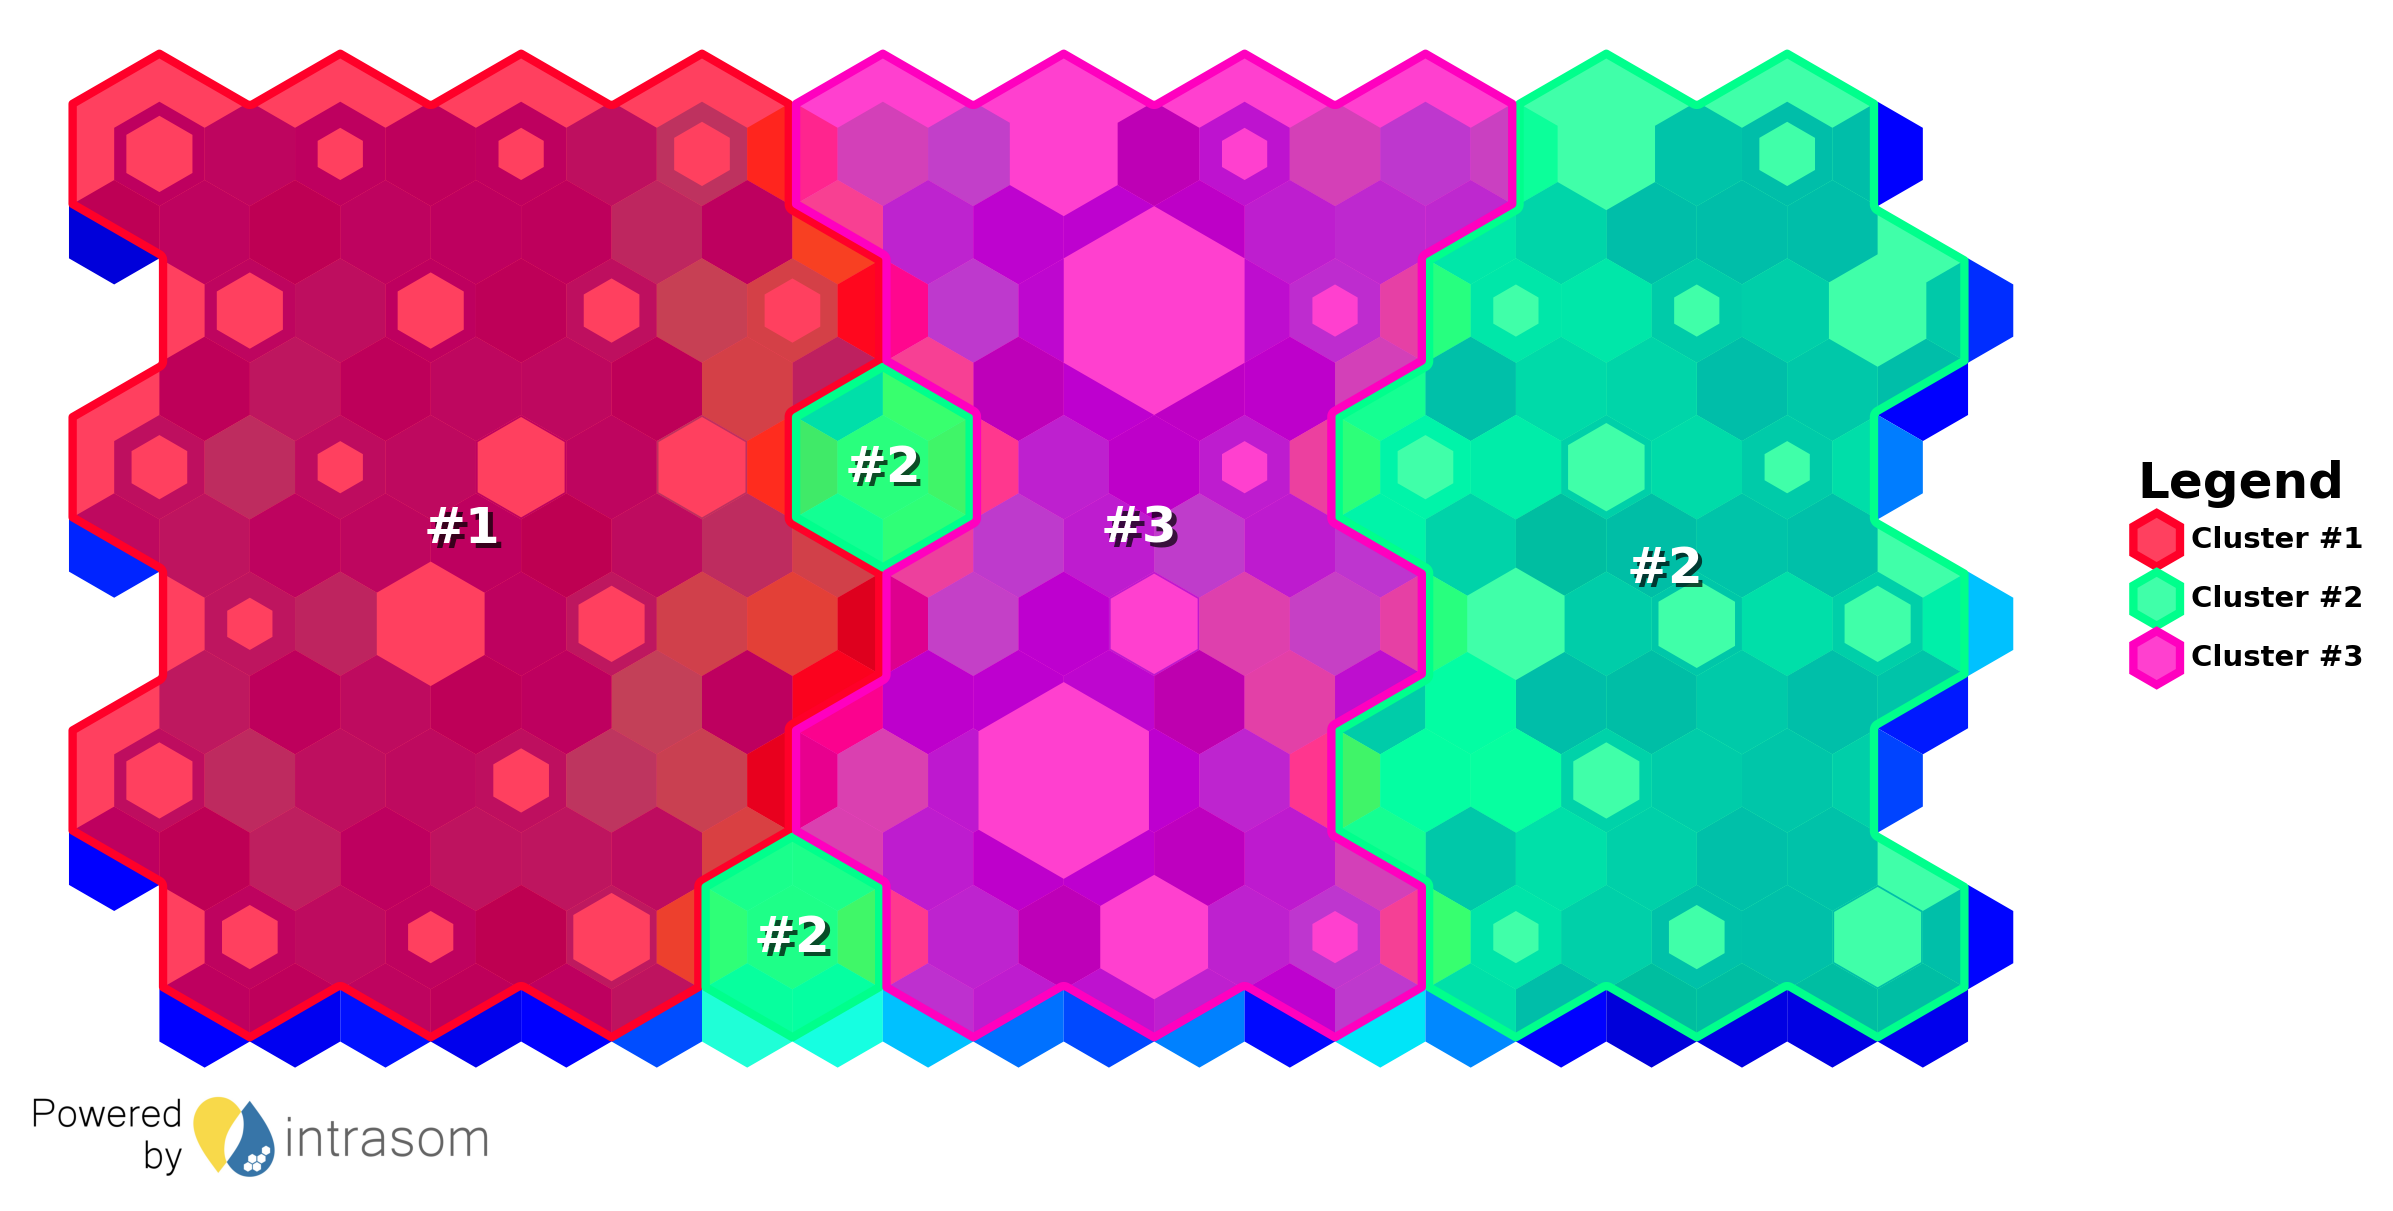

In [9]:
# Visualization of the clustered self-organized map
clustering_iris.plot_kmeans(
    figsize = (10,5),
    title = "",
    clusters = clusters_iris,
    title_size = 18,
    title_pad = 20,
    umatrix = True,
    colormap = "gist_rainbow",
    alfa_clust = 0.75,
    hits = True,
    legend_text_size = 7,
    cluster_outline = True,
    plot_labels = True)

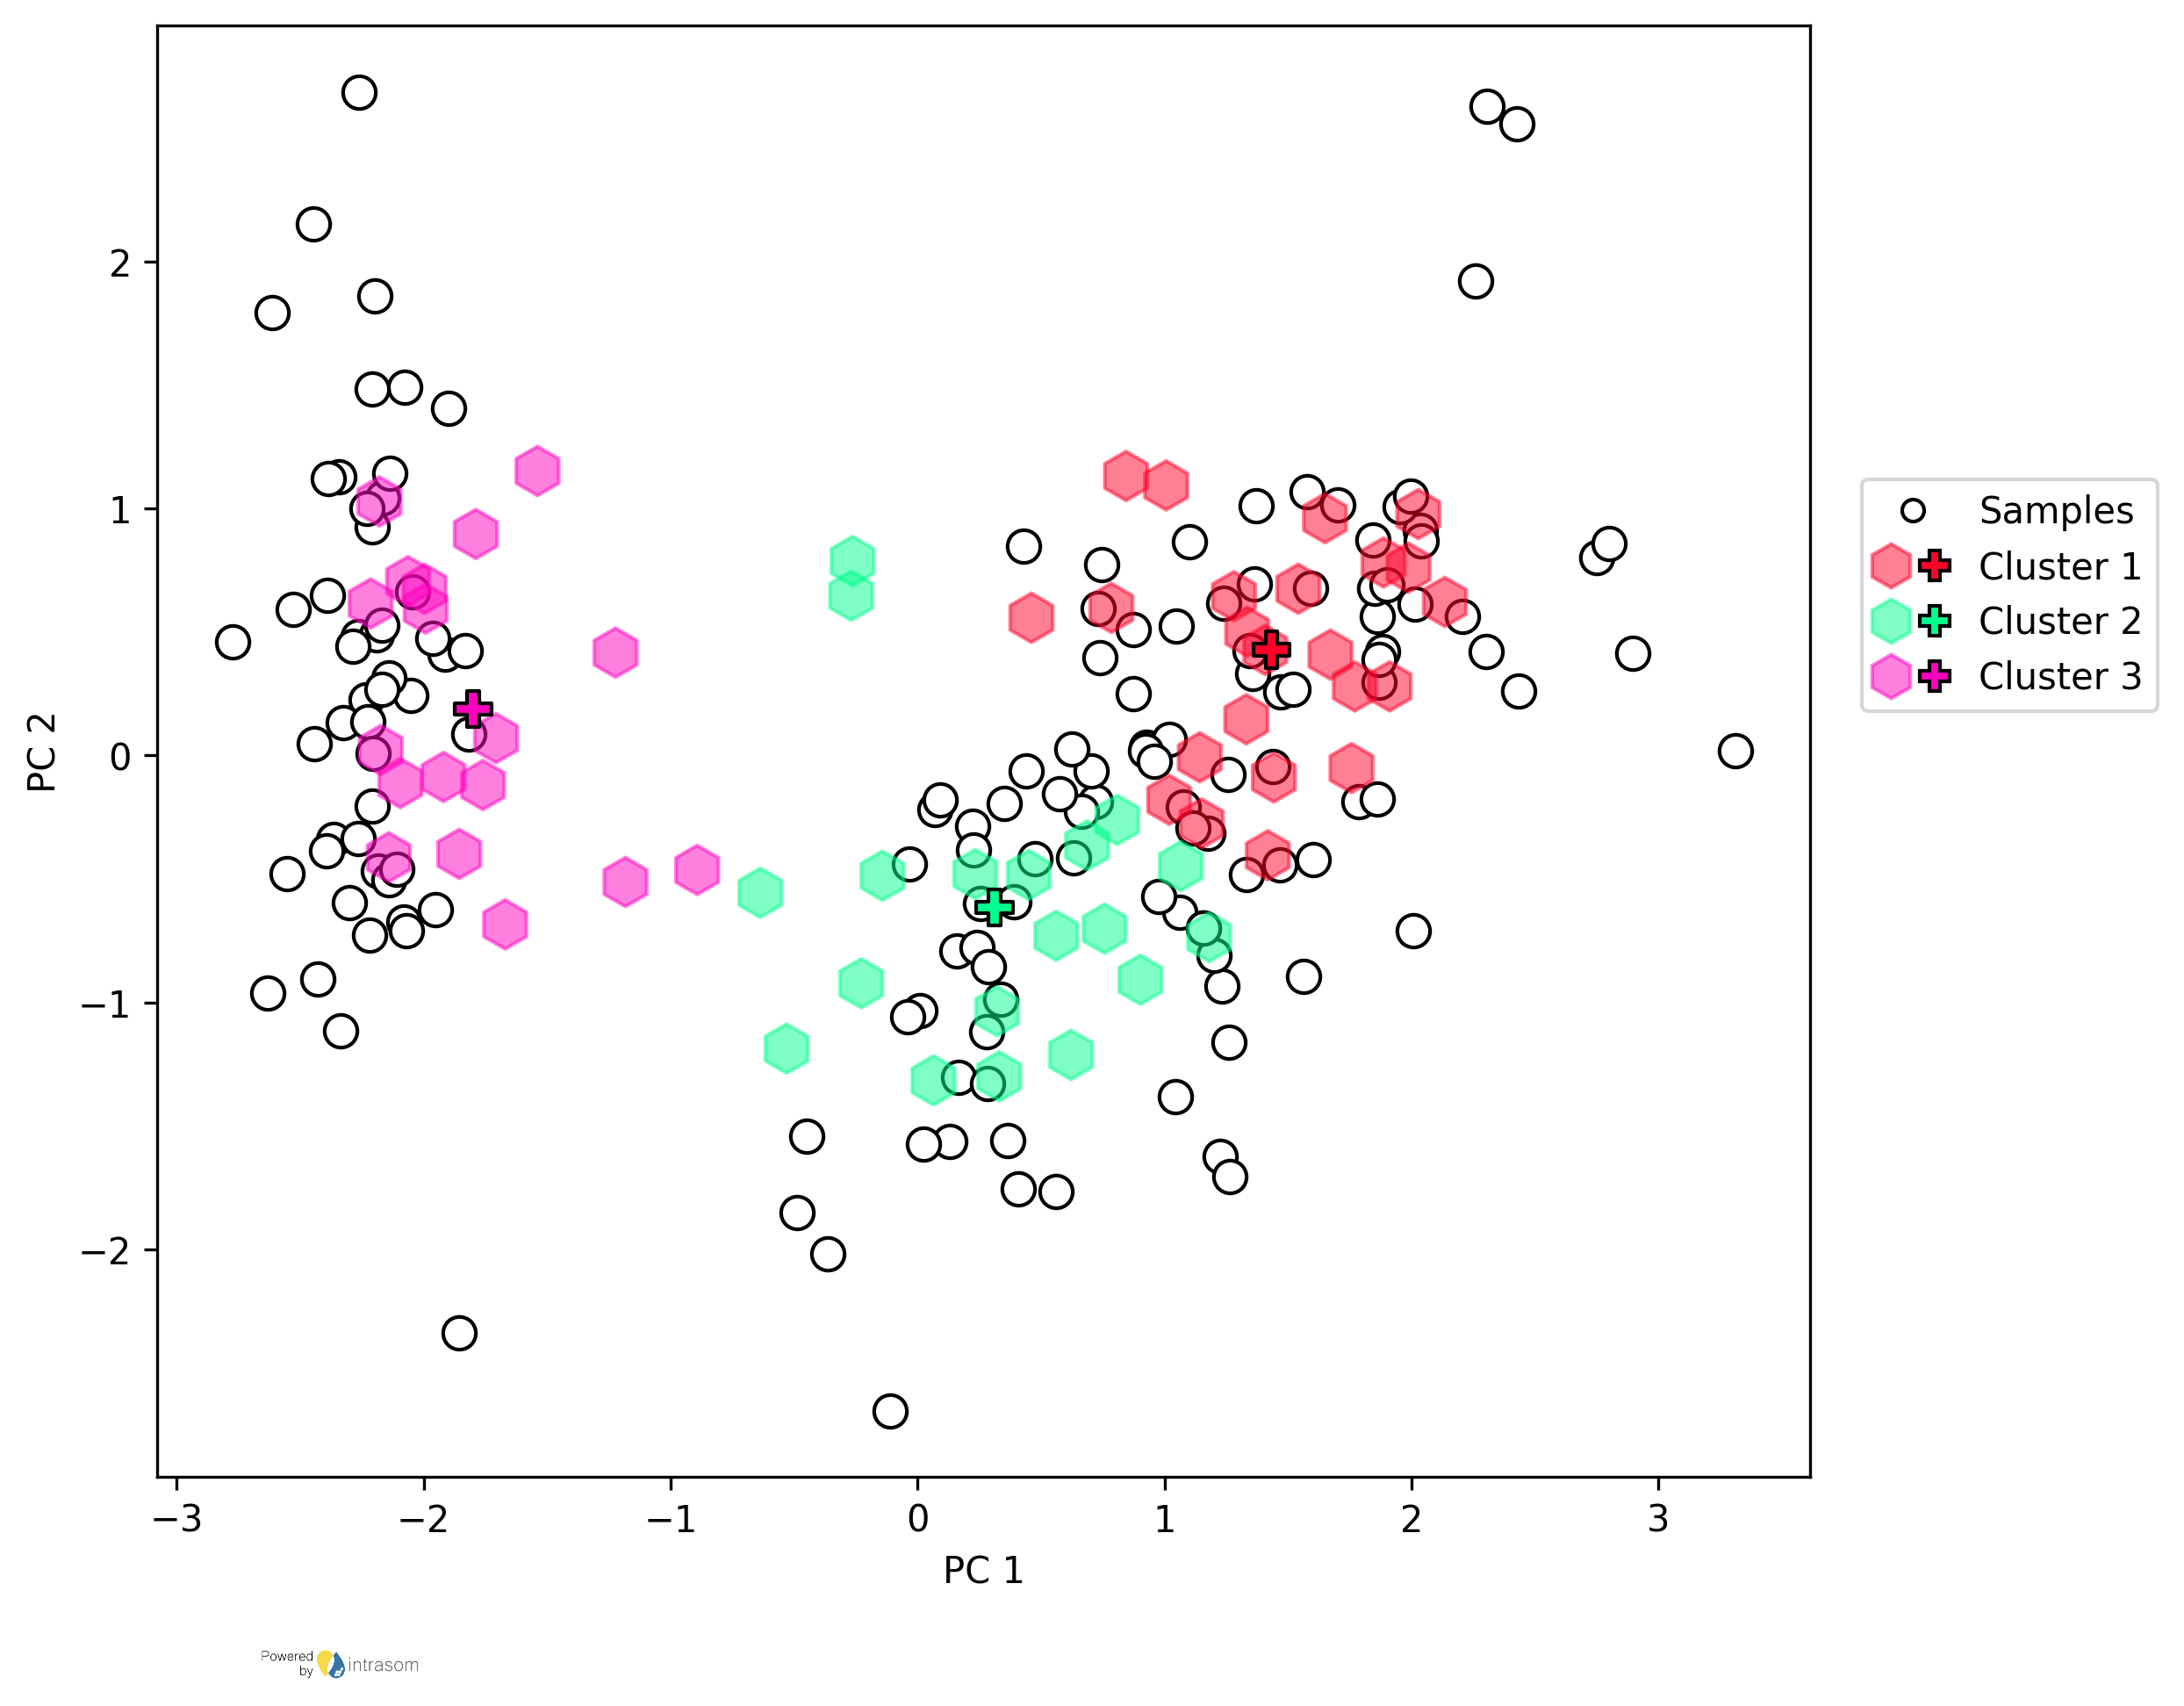

In [10]:
# Clusters of neurons in the PCA projection
clustering_iris.plot_clusters_pca(
    figsize = (9,9),
    normalization = 'var',
    title = '',
    show_samples = True,
    samples_size = 80,
    show_neurons=True,
    neurons_size = 180,
    show_centroids = True,
    centroids_size = 100,
    colormap='gist_rainbow',
    watermark_neurons=False,
    watermark_neurons_fontsize=5)

In [12]:
# Clustering of the self-organized map with K-means presents some advantages, such as reducing computational cost and improving fairness
# The classic K-means algorithm prioritizes cluster separation, while SOM enforces coverage fairness of the clusters in the data space
# Coverage fairness means that all data regions are represented, avoiding the dominance of large clusters over smaller ones

In [13]:
# Load cluster representativity module
representatives_iris = ClusterRepresentativity(clustering_iris)

# CMPF matrix, clusters weights and typical neurons of each cluster
neurons_responsibilities = representatives_iris.calculate_neurons_cmpf() # (n_neurons, n_clusters)
iris_clusters_weights = representatives_iris.clusters_weights
iris_typical_neurons = representatives_iris.cluster_representatives_indices
print(f'Weights of the clusters 1, 2 and 3, respectively: {iris_clusters_weights}')
print(f'Indices of the typical neurons of clusters 1, 2 and 3, respectively: {iris_typical_neurons}')

Weights of the clusters 1, 2 and 3, respectively: [0.3668788  0.47140545 0.16171576]
Indices of the typical neurons of clusters 1, 2 and 3, respectively: [33 58 46]


Total normalized overlap between all cluster pairs: 0.025529366980242555


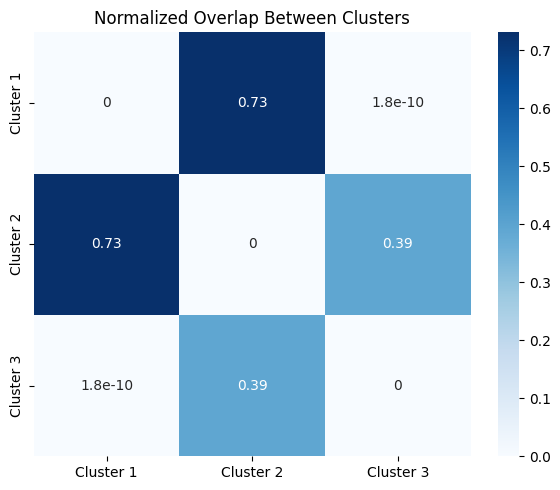

In [ ]:
def plot_cluster_overlap_heatmap(neurons_responsibilities):
    """
    Plots a heatmap of normalized overlap between all cluster pairs.
    neurons_responsibilities: numpy array or DataFrame of shape (n_neurons, n_clusters)
    """
    # Convert to numpy array if DataFrame
    arr = np.asarray(neurons_responsibilities)
    n_clusters = arr.shape[1]
    overlap_matrix = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            if i != j:
                overlap = np.sum(np.minimum(arr[:, i], arr[:, j]))
                min_sum = np.minimum(np.sum(arr[:, i]), np.sum(arr[:, j])) # to normalize the overlap value
                overlap_matrix[i, j] = overlap / min_sum if min_sum > 0 else 0.0 # intersection over area of the smallest cluster
    # Now compute the total overlap
    total_overlap = 0
    effective_responsibilities = np.sum(arr)
    for i in range(n_clusters):
        for j in range(i+1, n_clusters):
            if i < j:
                total_overlap += overlap_matrix[i, j]
    total_overlap = total_overlap / effective_responsibilities
    print(f'Total normalized overlap between all cluster pairs: {total_overlap}') # 1 is when all neurons belong equally to all clusters
    # Labeling
    labels = [f"Cluster {i+1}" for i in range(n_clusters)]
    # Plot
    plt.figure(figsize=(6, 5))
    sns.heatmap(overlap_matrix, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title('Normalized Overlap Between Clusters')
    plt.tight_layout()
    plt.show()

plot_cluster_overlap_heatmap(neurons_responsibilities)

In [15]:
representatives_iris.typical_sample_analysis()

,Sample_index,BMU,Cluster,CMPF_value,Silhouette,Samples_BMU_dists,Cluster_order
0,0,56,3,0.783973,0.732136,0.179274,3
1,1,16,3,0.711173,0.559495,0.370688,3
2,2,16,3,0.711173,0.672348,0.239187,3
3,3,16,3,0.711173,0.613291,0.268113,3
4,4,56,3,0.783973,0.726674,0.186991,3
...,...,...,...,...,...,...,...
145,145,12,1,0.641333,0.478653,0.386189,2
146,146,40,2,0.535952,0.166734,0.500717,1
147,147,12,1,0.641333,0.427380,0.211125,2
148,148,24,1,0.663259,0.398902,0.667482,2


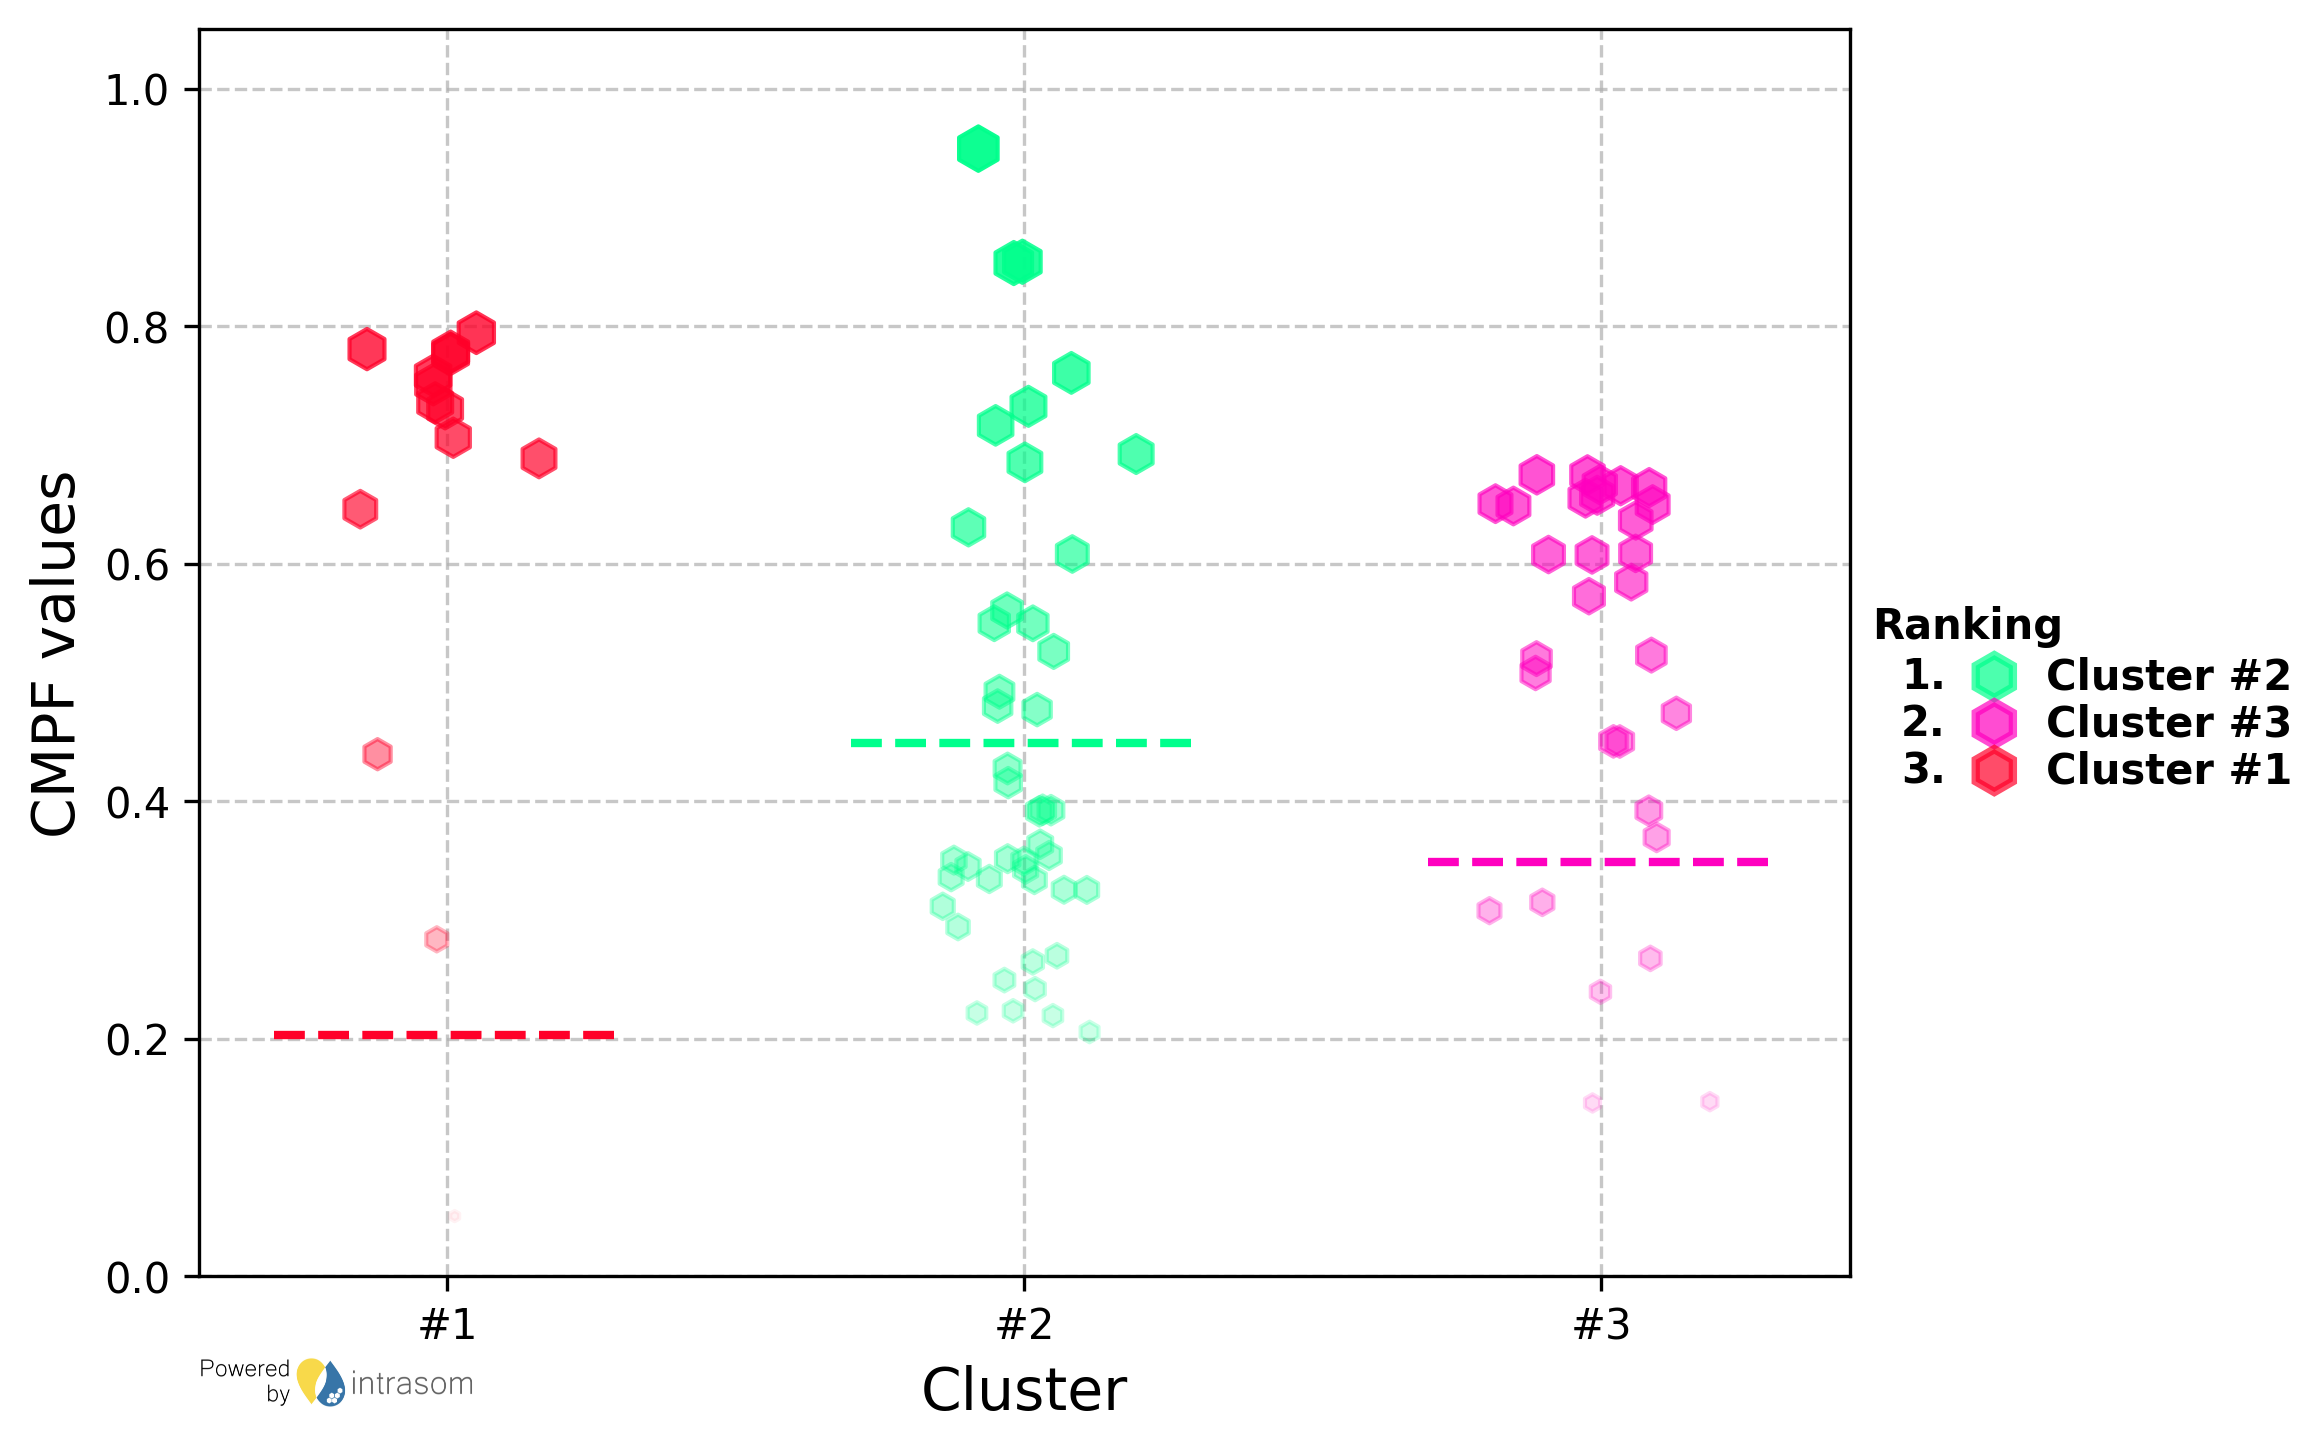

In [12]:
# It is possible to visualize the weights distribution in the jitterplot of the CMPF values of all neurons for each cluster
# Larger weights indicate that a cluster is close to a region with high concentration of neurons with more samples assigned to them, while smaller weights indicate that a cluster is isolated from these regions
representatives_iris.cmpf_jitter_plot(
    plot_width = 8,
    title = "",
    legend_title = "Ranking",
    yrange = [0.0,1.05],
    xlabel_size = 14,
    ylabel_size = 14,
    legend_title_size = 10,
    legend_text_size = 10,
    watermark_neurons = False)

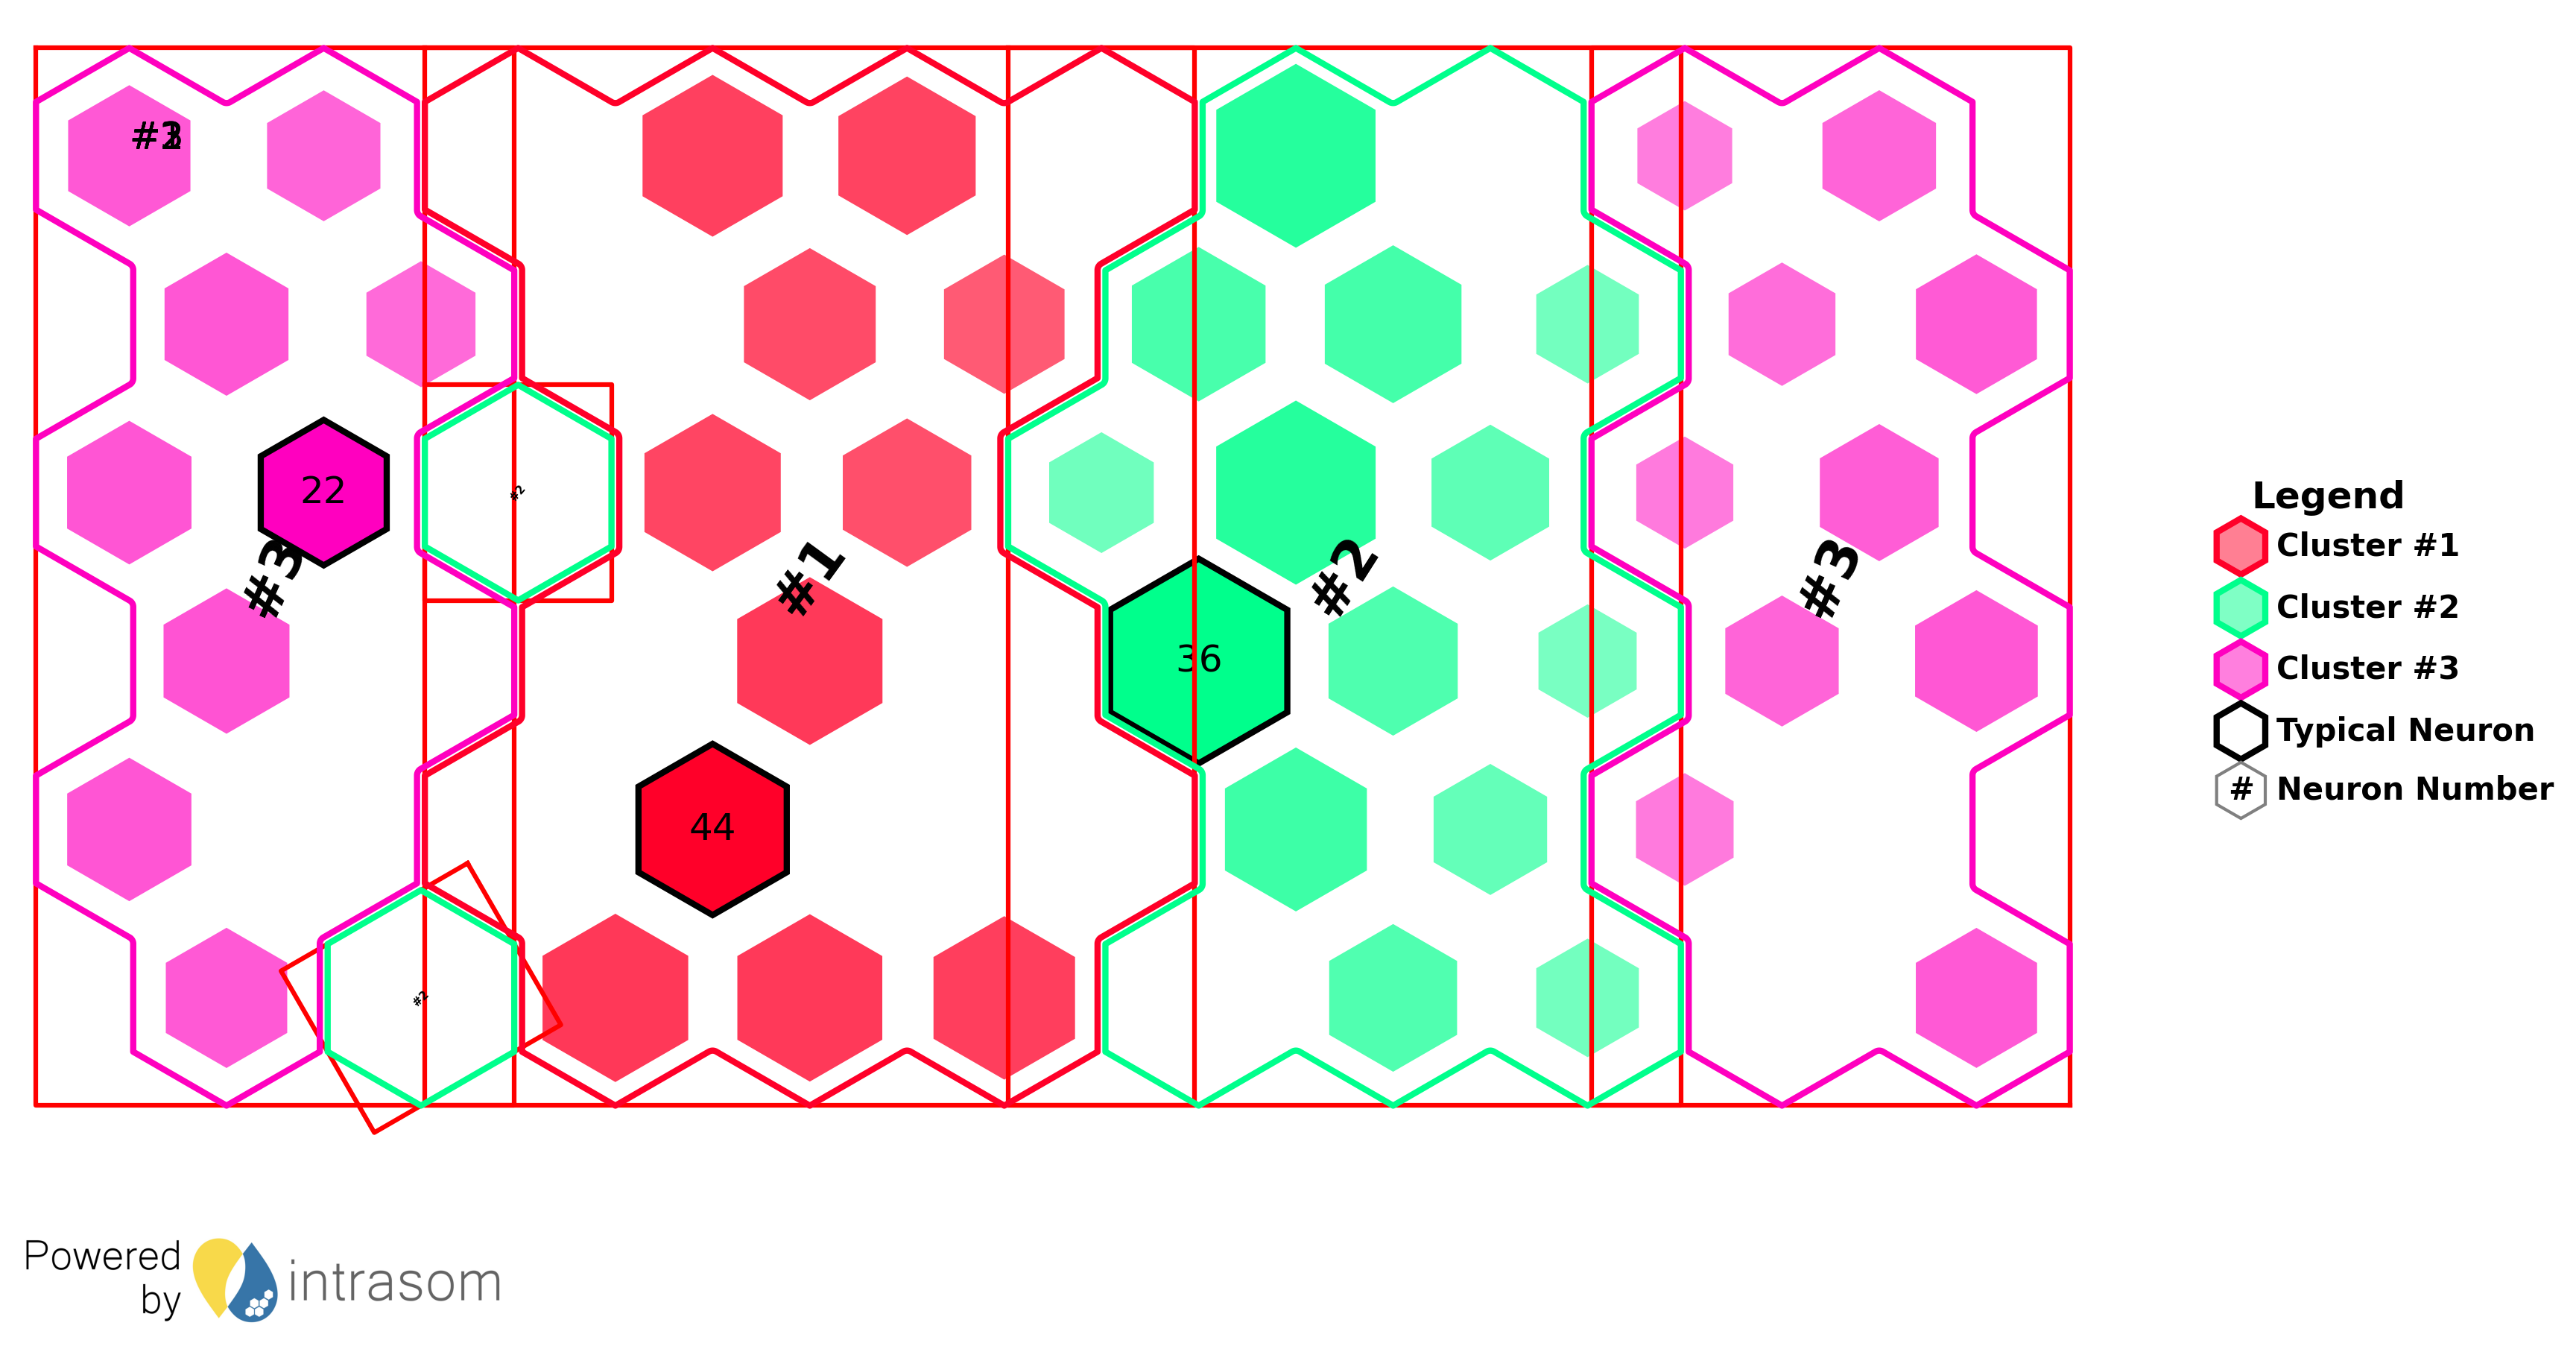

In [ ]:
# # In the SOM space, we can verify these regions by plotting the maximum CMPF value of each neuron (improve this code)
# representatives_iris.cmpf_som_plot(
#     figsize = (14,8),
#     watermark_neurons = False,
#     watermark_typical_neurons = True,
#     colormap = "gist_rainbow",
#     title = "",
#     plot_labels = True,
#     auto_adjust_text = True,
#     clusterout_maxtext_size = 12,
#     alfa_clust_legend = 0.5,
#     neuron_number_label = "Neuron Number",
#     typical_neuron_label = "Typical Neuron")

In [14]:
# Now, to select typical samples we can use different criteria obtained with the typical_sample_analysis method
typical_iris_analysis = representatives_iris.typical_sample_analysis()
typical_iris_analysis

,Sample_index,BMU,Cluster,CMPF_value,Silhouette,Samples_BMU_dists,Cluster_order
0,0,54,1,0.776556,0.741115,0.214202,3
1,1,15,1,0.645800,0.549325,0.332163,3
2,2,14,1,0.705985,0.671470,0.214828,3
3,3,14,1,0.705985,0.607036,0.344937,3
4,4,54,1,0.776556,0.736083,0.179714,3
...,...,...,...,...,...,...,...
145,145,20,3,0.648485,0.503231,0.380892,2
146,146,29,3,0.519980,-0.103372,0.435187,2
147,147,20,3,0.648485,0.463758,0.164819,2
148,148,22,3,0.674759,0.415289,0.662763,2


In [15]:
# These criteria are:
print(f'Samples with BMUs with highest CMPF values of each cluster: missing implementation.')
print(f'Samples with highest Silhouette Coefficient (SC) values of each cluster: {representatives_iris.sc_typical_samples_indices.values}')
print(f'Samples closest to the typical neuron of each cluster: {representatives_iris.cmpf_dists_typical_samples_indices.values}')

# Plot a PCA visualization comparing the three

Samples with BMUs with highest CMPF values of each cluster: missing implementation.
Samples with highest Silhouette Coefficient (SC) values of each cluster: [  0  69 139]
Samples closest to the typical neuron of each cluster: [124  79  48]


In [16]:
# Oversampling with GMM
# Plot the Silhouette plot for the CMPF, SC (separating for each cluster) and Samples_BMU_dists (ordering by cluster then by BMU)

# from sklearn.mixture import GaussianMixture
# from matplotlib.patches import Ellipse

# gmm = GaussianMixture(n_components=3, covariance_type='full', n_init=1, random_state=42)
# gmm_labels = gmm.fit_predict(iris.data)
# sampled_dataset = gmm.sample(n_samples=iris.data.shape[0])
# data = sampled_dataset[0]
# labels = sampled_dataset[1]
# plt.scatter(data[:,0], data[:,1], c=labels, cmap='gist_rainbow')
# plt.show()